Import Library & W&B

In [2]:
# === IMPORT LIBRARY ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import wandb

# === INIT W&B ===
wandb.init(project="uts-fraud-detection", name="experiment-3-models")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sitiyolandahareniza (sitiyolandahareniza-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Load Dataset

In [3]:
from sklearn.datasets import fetch_openml

data = fetch_openml(data_id=1597, as_frame=True)
df = data.frame

# 🔥 FIX ERROR DI SINI
df['Class'] = df['Class'].astype(int)

print(df['Class'].unique())

[0 1]


EDA

In [4]:
# === INFO DATA ===
df.info()

# === DESKRIPSI DATA ===
df.describe()

# === DISTRIBUSI TARGET ===
print("\nDistribusi Kelas:")
print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

Visualisasi Imbalance

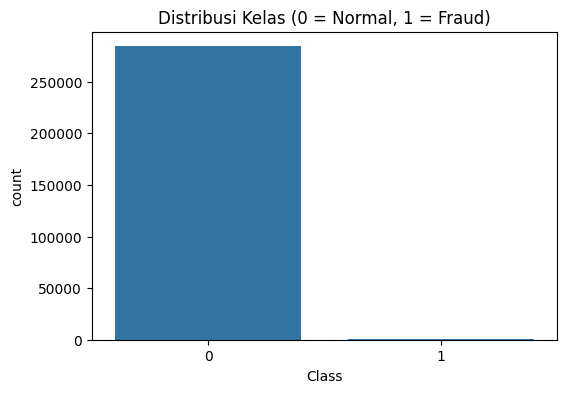

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Distribusi Kelas (0 = Normal, 1 = Fraud)")
plt.show()

Split Data

In [6]:
# === SPLIT DATA ===
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (199364, 29)
Test shape : (85443, 29)


SMOTE

In [7]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nSebelum SMOTE:")
print(y_train.value_counts())

print("\nSesudah SMOTE:")
print(y_train_res.value_counts())


Sebelum SMOTE:
Class
0    199008
1       356
Name: count, dtype: int64

Sesudah SMOTE:
Class
0    199008
1    199008
Name: count, dtype: int64


Logistic Regression

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

lr_pred = lr.predict(X_test)

Random Forest

In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

rf_pred = rf.predict(X_test)

XGBoost

In [10]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

Evaluasi Semua Model

In [11]:
def evaluate(y_test, y_pred, y_prob=None, name="Model"):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-Score :", f1)

    if y_prob is not None:
        auprc = average_precision_score(y_test, y_prob)
        print("AUPRC    :", auprc)

        wandb.log({f"{name}_AUPRC": auprc})

    wandb.log({
        f"{name}_Accuracy": acc,
        f"{name}_Precision": prec,
        f"{name}_Recall": rec,
        f"{name}_F1": f1
    })

# Jalankan evaluasi
evaluate(y_test, lr_pred, name="Logistic Regression")
evaluate(y_test, rf_pred, name="Random Forest")
evaluate(y_test, xgb_pred, xgb_prob, name="XGBoost")


=== Logistic Regression ===
Accuracy : 0.9798813243916997
Precision: 0.06819421713038734
Recall   : 0.9191176470588235
F1-Score : 0.12696800406297612

=== Random Forest ===
Accuracy : 0.9995552590615966
Precision: 0.855072463768116
Recall   : 0.8676470588235294
F1-Score : 0.8613138686131386

=== XGBoost ===
Accuracy : 0.999403110845827
Precision: 0.7814569536423841
Recall   : 0.8676470588235294
F1-Score : 0.8222996515679443
AUPRC    : 0.8894783694776558


Confusion Matrix

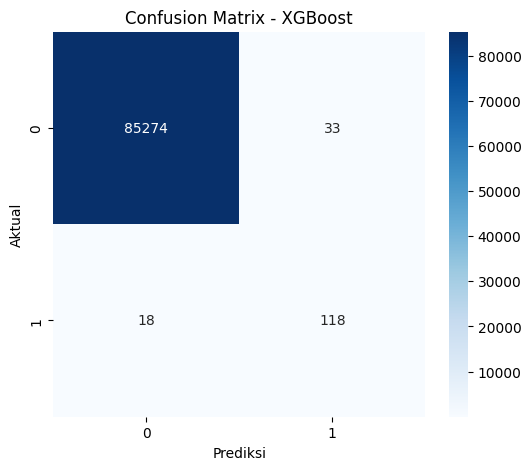

In [12]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

Feature Importance

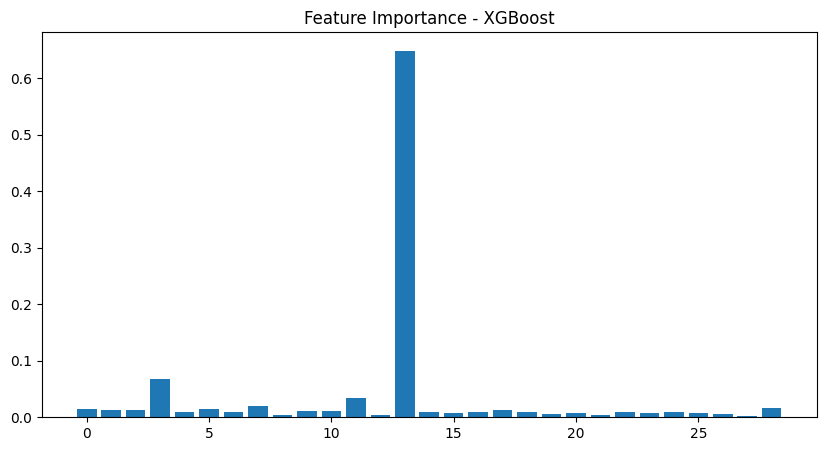

Logistic Regression_Accuracy,▁
Logistic Regression_F1,▁
Logistic Regression_Precision,▁
Logistic Regression_Recall,▁
Random Forest_Accuracy,▁
Random Forest_F1,▁
Random Forest_Precision,▁
Random Forest_Recall,▁
XGBoost_AUPRC,▁
XGBoost_Accuracy,▁
+3,...


In [13]:
importances = xgb.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - XGBoost")
plt.show()

wandb.finish()